# **🌡️ Temperature Forecasting: Time-Series Analysis & Machine Learning**

## Project Overview

A practical time-series forecasting project focused on analyzing historical temperature patterns, extracting temporal features, and comparing machine learning models for temperature forecasting. The workflow covers exploratory analysis, feature engineering, model development, and performance evaluation using both error metrics and actual-vs-forecasted visualizations.

---

## 📊 1. Exploratory Time-Series Analysis

Explore historical temperature patterns across years, months, and quarters to identify seasonal trends, variations, and relationships within the data.

### Key Focus Areas
* Dataset inspection and preprocessing
* Temporal feature engineering
* Yearly and quarterly temperature analysis
* Seasonal pattern exploration
* Year-to-year temperature comparisons

---

## 🤖 2. Temperature Forecasting

Develop machine learning models to forecast temperature using engineered temporal features and historical observations.

### Models Applied
* **Linear Regression**
* **Random Forest Regressor**

> The models are trained and used to generate temperature forecasts on the test dataset.

---

## 📈 3. Model Evaluation & Comparison

Evaluate and compare forecasting performance using multiple error metrics and visual analysis.

### Evaluation Metrics
* **MAE** (Mean Absolute Error)
* **RMSE** (Root Mean Squared Error)
* **$R^2$ Score** (Coefficient of Determination)

### Output & Visuals
The results are summarized in a comparative metrics table and visualized through:
* Model error comparison
* Actual vs. forecasted temperature plots

*This provides a practical view of not only which model performs better, but also how closely each model follows the observed temperature patterns.*

In [27]:
import pandas as pd

data = pd.read_csv("/content/temperature_data.csv")

data.head()

,Date,Temperature
0,1980-01-02,275.23980
1,1980-01-03,275.39957
2,1980-01-04,275.77197
3,1980-01-05,276.20398
4,1980-01-06,276.54490


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12784 entries, 0 to 12783
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         12784 non-null  object 
 1   Temperature  12784 non-null  float64
dtypes: float64(1), object(1)
memory usage: 199.9+ KB


In [29]:
data["Date"] = pd.to_datetime(data["Date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12784 entries, 0 to 12783
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         12784 non-null  datetime64[ns]
 1   Temperature  12784 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 199.9 KB


In [30]:
print("📊 Raw Dataset")
data.head(10)

📊 Raw Dataset


,Date,Temperature
0,1980-01-02,275.23980
1,1980-01-03,275.39957
2,1980-01-04,275.77197
3,1980-01-05,276.20398
4,1980-01-06,276.54490
5,1980-01-07,276.33997
6,1980-01-08,276.30075
7,1980-01-09,276.55362
8,1980-01-10,277.74973
9,1980-01-11,279.69140


In [31]:
# Creating New Columns

data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month
data["Month Name"] = data["Date"].dt.month_name()
data["Year"] = data["Date"].dt.year
data["Quarter"] = data["Date"].dt.quarter

print("🛠️ After Feature Engineering")
data.head()


🛠️ After Feature Engineering


,Date,Temperature,Day,Month,Month Name,Year,Quarter
0,1980-01-02,275.23980,2,1,January,1980,1
1,1980-01-03,275.39957,3,1,January,1980,1
2,1980-01-04,275.77197,4,1,January,1980,1
3,1980-01-05,276.20398,5,1,January,1980,1
4,1980-01-06,276.54490,6,1,January,1980,1


In [32]:
# Setting the Date column as index column

data.index = data["Date"]

data.drop(columns = ["Date"], inplace = True)

data.sample(10)

,Temperature,Day,Month,Month Name,Year,Quarter
Date,,,,,,
1988-09-03,295.42590,3,9,September,1988,3
2007-09-16,293.99258,16,9,September,2007,3
2014-08-11,296.65582,11,8,August,2014,3
1997-09-20,292.83020,20,9,September,1997,3
2008-12-27,277.85828,27,12,December,2008,4
2004-05-09,290.14868,9,5,May,2004,2
2000-10-29,285.13373,29,10,October,2000,4
2007-04-22,287.89938,22,4,April,2007,2
1998-08-30,294.86697,30,8,August,1998,3


<Axes: title={'center': 'Temperature Analysis Over Years'}, xlabel='Date'>

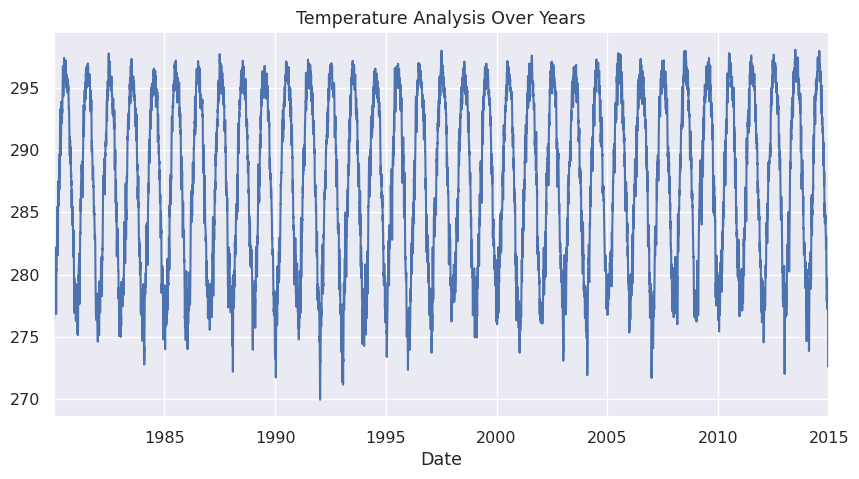

In [33]:
data["Temperature"].plot(kind = "line",title = "Temperature Analysis Over Years", figsize=(10,5))

In [34]:
print("No of Unique Years: ",data["Year"].nunique())

No of Unique Years:  36


In [35]:
year = 2012

df_year = data[data["Year"] == year]

print(
    df_year[["Temperature", "Quarter", "Year"]]
    .groupby(["Quarter", "Year"])
    .agg(["max", "mean", "min"])
)

             Temperature                       
                     max        mean        min
Quarter Year                                   
1       2012   285.73447  279.721565  274.55597
2       2012   297.21143  291.658160  284.70140
3       2012   297.67953  295.220977  290.97260
4       2012   291.27480  283.988747  276.91867


<Axes: title={'center': 'Average Temperature Analysis Quarterly of Year 2012'}, xlabel='Quarter'>

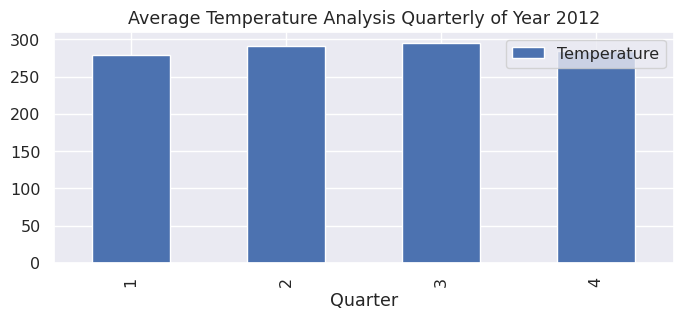

In [36]:
df_year[["Temperature", "Quarter"]] \
    .groupby("Quarter") \
    .mean() \
    .plot(
        kind="bar",
        title=f"Average Temperature Analysis Quarterly of Year {year}",
        figsize=(8,3)
    )

Text(0.5, 1.0, 'Yearly Temperature Comparison')

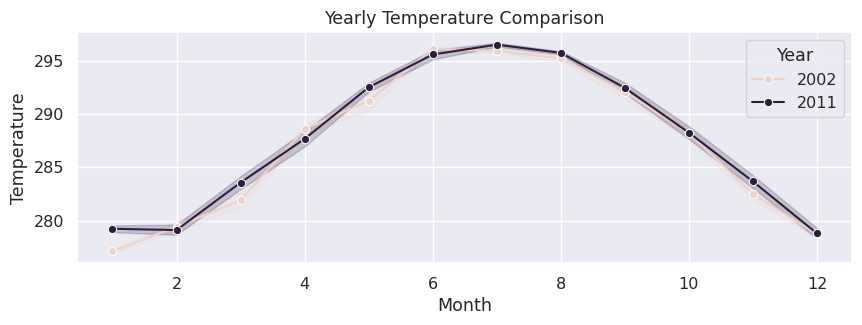

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

year_1 = 2002
year_2 = 2011

data_1 = data[data["Year"].isin([year_1,year_2])]
# For each year we wanna analyze average temperature
plt.figure(figsize = (10,3))
sns.lineplot(
    data=data_1,
    x="Month",
    y="Temperature",
    hue="Year",
    marker="o",
    estimator="mean"
)
plt.title("Yearly Temperature Comparison")

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, r2_score

In [39]:
x = data.drop(columns = ["Temperature","Month Name"])
y = data["Temperature"]

x_train, x_test, y_train, y_test = train_test_split(x,y)

In [40]:
model_LR =LinearRegression()

model_LR.fit(x_train,y_train)

pred_lr = model_LR.predict(x_test)

LinearRegression()

In [42]:
print("Root Mean Squared Error of LinearRegression Model: ", root_mean_squared_error(y_test, pred_lr))
print("Mean Absolute Error of LinearRegression Model: ", mean_absolute_error(y_test, pred_lr))
print("R2 Score of LinearRegression Model: ", r2_score(y_test, pred_lr))

Root Mean Squared Error of LinearRegression Model:  6.926498985477289
Mean Absolute Error of LinearRegression Model:  6.154220562169838
R2 Score of LinearRegression Model:  0.03423534464548861


In [49]:
# Evaluate N models and visualize their performance through
# comparative evaluation metrics and result plots.
def v_e(predictions, model_name, ax):
    sns.set_theme(     style="darkgrid",     context="notebook",     font_scale=1.05   )
    predictions_df = pd.DataFrame({
        "Actual": y_test.values,
        "Predictions": predictions
    })

    predictions_df.head(100).plot(
        kind="line",
        ax=ax,
        title=f"Actual vs Forecasted Temperature — {model_name}(100 Test Samples)",
        linewidth=2
    )

    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Temperature (°C)")

In [44]:
model_rf = RandomForestRegressor()

model_rf.fit(x_train, y_train)

pred_rf = model_rf.predict(x_test)

In [45]:
print("Root Mean Squared Error of Random Forest Model: ", root_mean_squared_error(y_test, pred_rf))
print("Mean Absolute Error of Random Forest Model: ", mean_absolute_error(y_test, pred_rf))
print("R2 Score of Random Forest Model: ", r2_score(y_test, pred_rf))

Root Mean Squared Error of Random Forest Model:  0.6720556779232073
Mean Absolute Error of Random Forest Model:  0.49236882869212073
R2 Score of Random Forest Model:  0.9909081080343842


In [46]:
# This Dictionary Holds complete evaulation for both of the Models and we can now easily comare the performance of the Models using this
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, pred_lr), mean_absolute_error(y_test, pred_rf)],
    "RMSE": [mean_absolute_error(y_test, pred_lr), root_mean_squared_error(y_test, pred_rf)],
    "R²": [ r2_score(y_test, pred_lr),  r2_score(y_test, pred_rf)]
})

metrics_df = metrics_df

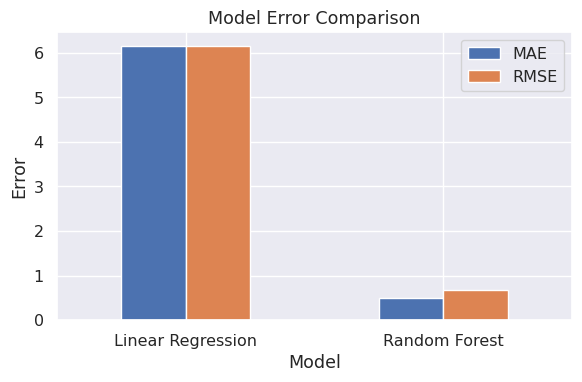

In [47]:
metrics_df[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(6, 4),
    title="Model Error Comparison"
)

plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(ticks=[0,1],labels = ["Linear Regression","Random Forest"],rotation=0)
plt.tight_layout()
plt.show()

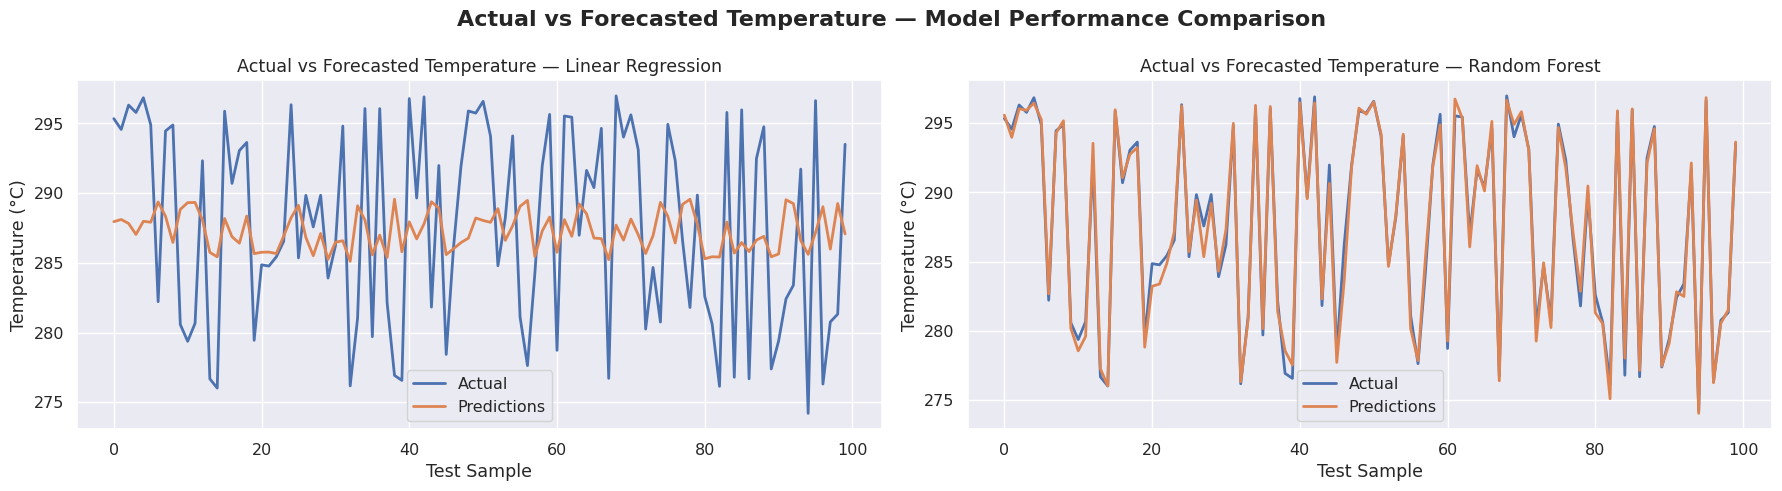

In [48]:

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "Actual vs Forecasted Temperature — Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)
v_e(pred_lr, "Linear Regression", axes[0])
v_e(pred_rf, "Random Forest", axes[1])
plt.tight_layout()
plt.show()